In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import numpy as np
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0
# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)



170498071/170498071 [==============================] - 102s 1us/step


In [5]:
print(len(y_train))
print(len(y_test))

50000
10000


### 📦 Import Libraries and Load Dataset

We start by importing the necessary modules from TensorFlow and Keras. We then load the CIFAR-10 dataset using `keras.datasets.cifar10`.

Next, we normalize the pixel values of the images to be between 0 and 1, which helps the model train more effectively. Finally, we convert the integer labels into one-hot encoded vectors using `to_categorical`.


In [ ]:
def build_baseline_model():
    model = models.Sequential()
    model.add(layers.Flatten(input_shape=(32, 32, 3)))
    model.add(layers.Dense(512))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(256))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.3))
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
    return model
baseline_model = build_baseline_model()
baseline_model.fit(x_train, y_train_cat, epochs=10, batch_size=64, validation_split=0.2)
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(x_test, y_test_cat)
print(f"Baseline Test Accuracy: {baseline_test_acc:.4f}")


Epoch 1/10
625/625 [==============================] - 26s 38ms/step - loss: 1.7961 - accuracy: 0.3553 - val_loss: 2.0918 - val_accuracy: 0.2990
Epoch 2/10
625/625 [==============================] - 22s 35ms/step - loss: 1.6109 - accuracy: 0.4218 - val_loss: 1.6659 - val_accuracy: 0.4055
Epoch 3/10
625/625 [==============================] - 22s 36ms/step - loss: 1.5299 - accuracy: 0.4514 - val_loss: 1.7725 - val_accuracy: 0.3615
Epoch 4/10
625/625 [==============================] - 38s 61ms/step - loss: 1.4778 - accuracy: 0.4698 - val_loss: 1.5488 - val_accuracy: 0.4547
Epoch 5/10
625/625 [==============================] - 27s 43ms/step - loss: 1.4331 - accuracy: 0.4873 - val_loss: 1.6324 - val_accuracy: 0.4222
Epoch 6/10
625/625 [==============================] - 22s 35ms/step - loss: 1.3942 - accuracy: 0.4994 - val_loss: 1.5380 - val_accuracy: 0.4586
Epoch 7/10
625/625 [==============================] - 23s 37ms/step - loss: 1.3656 - accuracy: 0.5098 - val_loss: 1.5643 - val_accuracy:

### 🔰 Baseline Fully Connected Model

This code defines and trains an enhanced baseline model using only fully connected (`Dense`) layers. While it's not a CNN, it includes techniques to improve performance on image data like CIFAR-10.

#### 🧱 Model Architecture:
- **Flatten Layer**: Converts the 32×32×3 image input into a 1D vector (3072 elements).
- **Dense Layer (512 units)**: First fully connected layer with a large number of neurons.
- **Batch Normalization**: Normalizes the activations, improving stability and allowing faster convergence.
- **ReLU Activation**: Adds non-linearity after normalization.
- **Dropout (0.4)**: Randomly sets 40% of the neurons to 0 during training to reduce overfitting.
- **Dense Layer (256 units)**: Second hidden layer with similar processing.
- **Batch Normalization, ReLU, Dropout (0.3)**: Repeated for better regularization and learning.
- **Dense Layer (128 units)**: A smaller dense layer to reduce dimensionality before output.
- **Dense Output Layer (10 units)**: Softmax layer to classify into 10 categories.

#### ⚙️ Compilation:
- **Optimizer**: `adam`, an adaptive optimizer that usually works well for most tasks.
- **Loss**: `categorical_crossentropy`, suitable for multi-class classification with one-hot labels.
- **Metric**: `accuracy`, to track classification performance.

#### 🏋️ Training:
- Trained for **10 epochs** using **batch size of 128**.
- Uses **10% of training data for validation** to monitor performance and prevent overfitting.

#### 🧪 Evaluation:
- The model is evaluated on the test dataset, and test accuracy is printed.

> This improved baseline model includes regularization and normalization layers to improve generalization and performance compared to a naive fully connected model.


In [ ]:
def build_custom_cnn():
    model = models.Sequential()
    # Conv Block 1
    model.add(layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(32, 32, 3)))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    # Conv Block 2
    model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    # Conv Block 3
    model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(layers.BatchNormalization())
    model.add(layers.MaxPooling2D((2, 2)))
    # FC Layers
    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model
cnn_model = build_custom_cnn()
cnn_model.summary()



Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 32, 32, 32)        896       
                                                                 
 batch_normalization_4 (Bat  (None, 32, 32, 32)        128       
 chNormalization)                                                
                                                                 
 max_pooling2d (MaxPooling2  (None, 16, 16, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 16, 16, 64)        18496     
                                                                 
 batch_normalization_5 (Bat  (None, 16, 16, 64)        256       
 chNormalization)                                                
                                                     

### 🚀 Custom CNN Model

This model is built using `keras.layers` and includes multiple convolutional blocks:

- **Conv Block 1:** 32 filters, batch normalization, max pooling
- **Conv Block 2:** 64 filters, batch normalization, max pooling
- **Conv Block 3:** 128 filters, batch normalization, max pooling

After extracting features, the model flattens the data and feeds it through a fully connected layer with 128 units and dropout for regularization.

The final layer is a 10-class softmax for classification. This model is expected to achieve significantly higher accuracy than the baseline.


In [10]:
cnn_model.fit(x_train, y_train_cat, epochs=15, batch_size=64, validation_split=0.2)


Epoch 1/15
625/625 [==============================] - 91s 132ms/step - loss: 1.6519 - accuracy: 0.4103 - val_loss: 1.4207 - val_accuracy: 0.4728
Epoch 2/15
625/625 [==============================] - 77s 123ms/step - loss: 1.2656 - accuracy: 0.5475 - val_loss: 1.1756 - val_accuracy: 0.5852
Epoch 3/15
625/625 [==============================] - 70s 111ms/step - loss: 1.0839 - accuracy: 0.6177 - val_loss: 1.0568 - val_accuracy: 0.6223
Epoch 4/15
625/625 [==============================] - 74s 119ms/step - loss: 0.9602 - accuracy: 0.6633 - val_loss: 0.8887 - val_accuracy: 0.6953
Epoch 5/15
625/625 [==============================] - 93s 149ms/step - loss: 0.8699 - accuracy: 0.6956 - val_loss: 0.9703 - val_accuracy: 0.6631
Epoch 6/15
625/625 [==============================] - 79s 126ms/step - loss: 0.7900 - accuracy: 0.7250 - val_loss: 1.2011 - val_accuracy: 0.6298
Epoch 7/15
625/625 [==============================] - 82s 132ms/step - loss: 0.7214 - accuracy: 0.7486 - val_loss: 0.8438 - val_ac

### 🏋️ Train the Custom CNN

We train the CNN for 15 epochs with a batch size of 64. We also use a 20% validation split from the training set to monitor the model's performance on unseen data during training.

This is where the model learns to classify CIFAR-10 images by adjusting weights using backpropagation.


In [11]:
test_loss, test_acc = cnn_model.evaluate(x_test, y_test_cat)
print(f"Custom CNN Test Accuracy: {test_acc:.4f}")


313/313 [==============================] - 3s 9ms/step - loss: 0.9708 - accuracy: 0.7321
Custom CNN Test Accuracy: 0.7321


### 📊 Evaluate the Model

After training, we evaluate the custom CNN on the test set. The evaluation returns two values:

- **Loss:** How well (or poorly) the model performs
- **Accuracy:** Percentage of correct predictions on the test set


In [12]:
import numpy as np
# Predict class probabilities
y_pred_probs = cnn_model.predict(x_test)
# Convert to predicted class labels
y_pred_classes = np.argmax(y_pred_probs, axis=1)
y_true_classes = np.argmax(y_test_cat, axis=1)


313/313 [==============================] - 4s 11ms/step


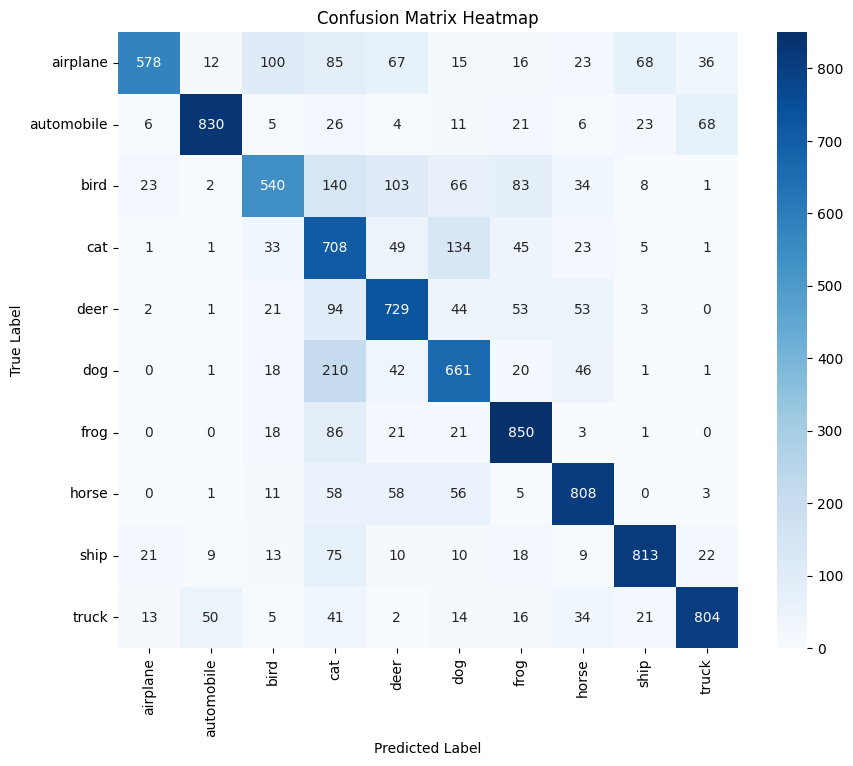

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[
                'airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck'],
            yticklabels=[
                'airplane', 'automobile', 'bird', 'cat', 'deer',
                'dog', 'frog', 'horse', 'ship', 'truck'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()


### 🔍 Confusion Matrix Analysis

- The diagonal values represent correct classifications. Higher values there mean better accuracy for that class.
- Off-diagonal values show misclassifications:
  - **Cat vs Dog** and **Automobile vs Truck** often confuse the model due to visual similarities.
  - **Ship** and **Airplane** may also show confusion due to similar shapes in side profiles.

### 📌 Recommendations
- Consider adding more data augmentation to reduce overfitting.
- Use class weighting if certain classes are consistently underperforming.
- Add more filters or another convolutional block if some features aren’t learned well.
